# Deep Learning for NLP: Embedding + LSTM Text Classification

Build a sentiment classifier for `tf.keras.datasets.imdb` movie reviews using a Keras `Embedding` layer (learned end-to-end) feeding into an `LSTM`. The focus here is the embedding-layer framing and padding/truncating of sequences, in contrast to the classical BOW/TF-IDF (topic 02) and self-supervised Word2Vec (topic 03) representations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print("TF version:", tf.__version__)

I0000 00:00:1787473227.718569   34636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787473227.718982   34636 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787473228.008027   34636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787473229.241686   34636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787473229.241997   34636 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0


## Load IMDB reviews

Each review is already integer-encoded by Keras (one integer per word, ranked by frequency). We restrict the vocabulary to the 10,000 most frequent words.

In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Train reviews:", len(X_train_full), "Test reviews:", len(X_test))
print("Raw (unpadded) length of first review:", len(X_train_full[0]))
print("First review as integer indices (first 20):", X_train_full[0][:20])
print("Label:", y_train_full[0], "(1 = positive, 0 = negative)")

/home/yashwanth-aravind/ml-course/python-bootcamp/.venv/lib/python3.13/site-packages/keras/src/datasets/npz_utils.py:68: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return RestrictedUnpickler(fp).load()


Train reviews: 25000 Test reviews: 25000
Raw (unpadded) length of first review: 218
First review as integer indices (first 20): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label: 1 (1 = positive, 0 = negative)


## Padding / truncating sequences

The `Embedding` and `LSTM` layers need fixed-length batches, so every review is padded or truncated to `MAX_LEN=200` tokens (default `pre`-padding/`post`-truncating).

In [3]:
X_train_full = pad_sequences(X_train_full, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

val_split = 5000
X_train, X_val = X_train_full[:-val_split], X_train_full[-val_split:]
y_train, y_val = y_train_full[:-val_split], y_train_full[-val_split:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Padded first review (first 30 tokens):", X_train[0][:30])

Train: (20000, 200) Val: (5000, 200) Test: (25000, 200)
Padded first review (first 30 tokens): [   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38]


## Build the Embedding + LSTM model

The `Embedding` layer learns a 32-dimensional dense vector per word index from scratch, jointly with the rest of the network — this is the 'learned' embedding contrasted with a pretrained Word2Vec embedding in `notes.md`.

In [4]:
model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

E0000 00:00:1787473232.899593   34636 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787473232.899898   34707 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787473232.997253   34636 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8, batch_size=128,
    callbacks=[early_stop], verbose=2)

Epoch 1/8


157/157 - 7s - 42ms/step - accuracy: 0.7340 - loss: 0.5197 - val_accuracy: 0.8550 - val_loss: 0.3524


Epoch 2/8


157/157 - 6s - 36ms/step - accuracy: 0.8928 - loss: 0.2688 - val_accuracy: 0.8784 - val_loss: 0.2993


Epoch 3/8


157/157 - 6s - 37ms/step - accuracy: 0.9186 - loss: 0.2171 - val_accuracy: 0.8564 - val_loss: 0.3774


Epoch 4/8


157/157 - 6s - 37ms/step - accuracy: 0.9326 - loss: 0.1860 - val_accuracy: 0.8468 - val_loss: 0.4219


Epoch 5/8


157/157 - 6s - 37ms/step - accuracy: 0.9272 - loss: 0.1889 - val_accuracy: 0.8392 - val_loss: 0.4553


## Training curves

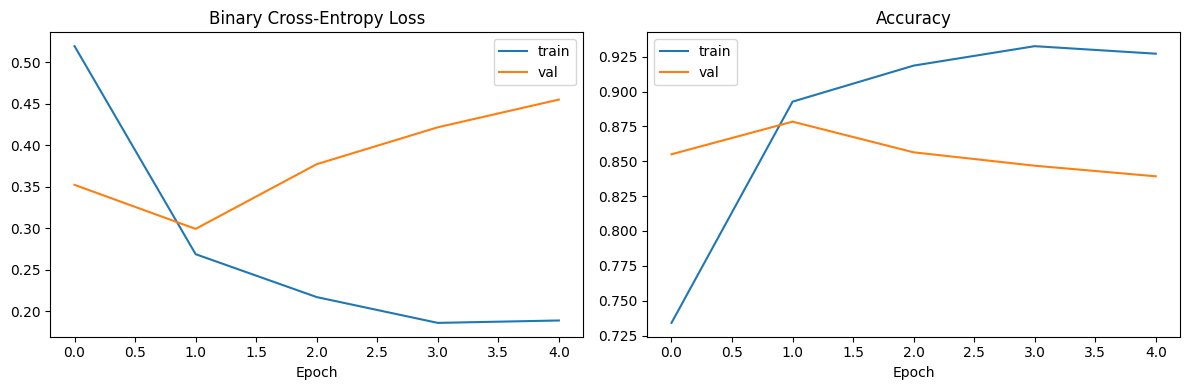

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("Binary Cross-Entropy Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()

plt.tight_layout()
plt.show()

## Test set evaluation

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.3144
Test accuracy: 0.8694


## Decode example reviews and compare true vs. predicted sentiment

Use `imdb.get_word_index()` to map integer indices back to words, then show 3-4 example reviews next to their true and predicted sentiment.

In [8]:
word_index = keras.datasets.imdb.get_word_index()
# Keras reserves indices 0-3 for padding/start/unknown/unused
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<UNK>"
reverse_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_index.get(i, "?") for i in encoded_review if i != 0)

sample_indices = [0, 1, 2, 3]
predictions = model.predict(X_test[sample_indices], verbose=0).ravel()

for idx, pred in zip(sample_indices, predictions):
    decoded = decode_review(X_test[idx])
    true_label = "positive" if y_test[idx] == 1 else "negative"
    pred_label = "positive" if pred >= 0.5 else "negative"
    print(f"--- Review #{idx} ---")
    print(decoded[:400] + ("..." if len(decoded) > 400 else ""))
    print(f"True: {true_label} | Predicted: {pred_label} (score={pred:.3f})")
    print()

      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/1641221 ━━━━━━━━━━━━━━━━━━━━ 6s 4us/step

  40960/1641221 ━━━━━━━━━━━━━━━━━━━━ 4s 3us/step

  65536/1641221 ━━━━━━━━━━━━━━━━━━━━ 4s 3us/step

 106496/1641221 ━━━━━━━━━━━━━━━━━━━━ 3s 2us/step

...

1466368/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1531904/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1581056/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


--- Review #0 ---
<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss
True: negative | Predicted: negative (score=0.106)

--- Review #1 ---
psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here and there i think what really makes this film work is the brilliant performance by sandy dennis it's definitely one of her darker characters but she plays it so perfectly and convincingly that it's scary michael bur...
True: positive | Predicted: positive (score=0.975)

--- Review #2 ---
everyone's horror the <UNK> promptly eats the mayor and then goes on a merry rampage <UNK

The `Embedding` layer, learned purely from the sentiment-classification objective (no separate Word2Vec-style pretraining step), combined with the `LSTM`'s ability to carry information across the whole padded 200-token sequence, is enough to reach solid test accuracy and produce sensible sentiment predictions on held-out reviews.